<a href="https://colab.research.google.com/github/Yousef-Shihade/information-retrieval-course-tasks/blob/main/Task_04_PPMI_Matrix/PPMI_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Co-occurrence mtrix ( first 5 rows ) : 


,data,model,training,testing,accuracy,loss,regression,classification,clustering,features,labels,prediction,algorithm,dataset,variance,bias,optimization,gradient,neuralnetwork,overfitting
data,0.0,14.0,10.0,5.0,25.0,21.0,17.0,11.0,23.0,15.0,12.0,12.0,6.0,2.0,15.0,24.0,1.0,24.0,23.0,7.0
model,17.0,0.0,12.0,42.0,39.0,29.0,1.0,74.0,16.0,25.0,42.0,64.0,60.0,15.0,28.0,38.0,30.0,1.0,45.0,8.0
training,20.0,50.0,0.0,51.0,41.0,27.0,26.0,30.0,12.0,25.0,23.0,5.0,34.0,58.0,14.0,34.0,8.0,21.0,35.0,18.0
testing,6.0,31.0,37.0,0.0,52.0,24.0,4.0,46.0,23.0,19.0,5.0,17.0,42.0,46.0,24.0,45.0,47.0,12.0,50.0,16.0
accuracy,6.0,38.0,35.0,7.0,0.0,46.0,5.0,45.0,0.0,22.0,44.0,43.0,37.0,26.0,39.0,15.0,43.0,17.0,25.0,28.0


 PPMI mtrix:


,data,model,training,testing,accuracy,loss,regression,classification,clustering,features,labels,prediction,algorithm,dataset,variance,bias,optimization,gradient,neuralnetwork,overfitting
data,0.000000,0.136386,0.000000,0.000000,1.549080,0.603167,2.073607,0.000000,2.040220,1.838587,0.317350,0.000000,0.000000,0.000000,0.308072,0.896507,0.000000,2.364655,0.750714,0.000000
model,0.416494,0.000000,0.000000,0.694877,0.587961,0.000000,0.000000,1.045445,0.000000,0.972888,0.522040,0.454562,0.687029,0.000000,0.000000,0.000000,0.060072,0.000000,0.116340,0.000000
training,0.818687,0.537951,0.000000,1.142712,0.827839,0.000000,1.251646,0.000000,0.000000,1.140615,0.000000,0.000000,0.035328,0.769777,0.000000,0.000000,0.000000,0.737073,0.000000,0.000000
testing,0.000000,0.256756,0.679740,0.000000,1.579191,0.000000,0.000000,0.935746,1.013748,1.153151,0.000000,0.000000,0.748648,0.843823,0.000000,0.776925,1.283963,0.338183,0.844536,0.000000
accuracy,0.000000,0.550487,0.599570,0.000000,0.000000,0.707940,0.000000,0.904037,0.000000,1.364655,1.165347,0.457019,0.565784,0.020701,0.660111,0.000000,1.155639,0.840683,0.000000,0.660111
loss,0.117741,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.390235,0.380775,0.000000,0.739462,0.000000,0.000000,0.580084,0.172188,0.318619,0.164283,0.146310,0.000000,0.112579
regression,2.378461,0.000000,0.551207,0.000000,0.129597,0.000000,0.000000,1.193543,0.000000,0.793499,0.246267,0.812114,0.960812,0.000000,0.000000,0.825423,0.000000,2.357703,0.000000,1.518639
classification,0.000000,0.000000,0.588681,0.000000,0.366380,0.000000,0.885421,0.000000,1.193543,0.608581,0.000000,0.000000,0.000000,0.807890,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
clustering,1.908976,0.614434,0.725578,0.577649,1.190626,0.000000,2.156069,0.193543,0.000000,2.217098,0.000000,0.000000,0.611621,0.101621,0.000000,0.000000,0.148164,0.172010,0.000000,1.108047
features,2.019159,0.416494,0.000000,1.605663,0.000000,0.000000,0.000000,0.000000,2.217098,0.000000,0.054315,0.701083,0.083242,0.594661,0.000000,0.000000,1.148164,2.534580,0.000000,1.271546


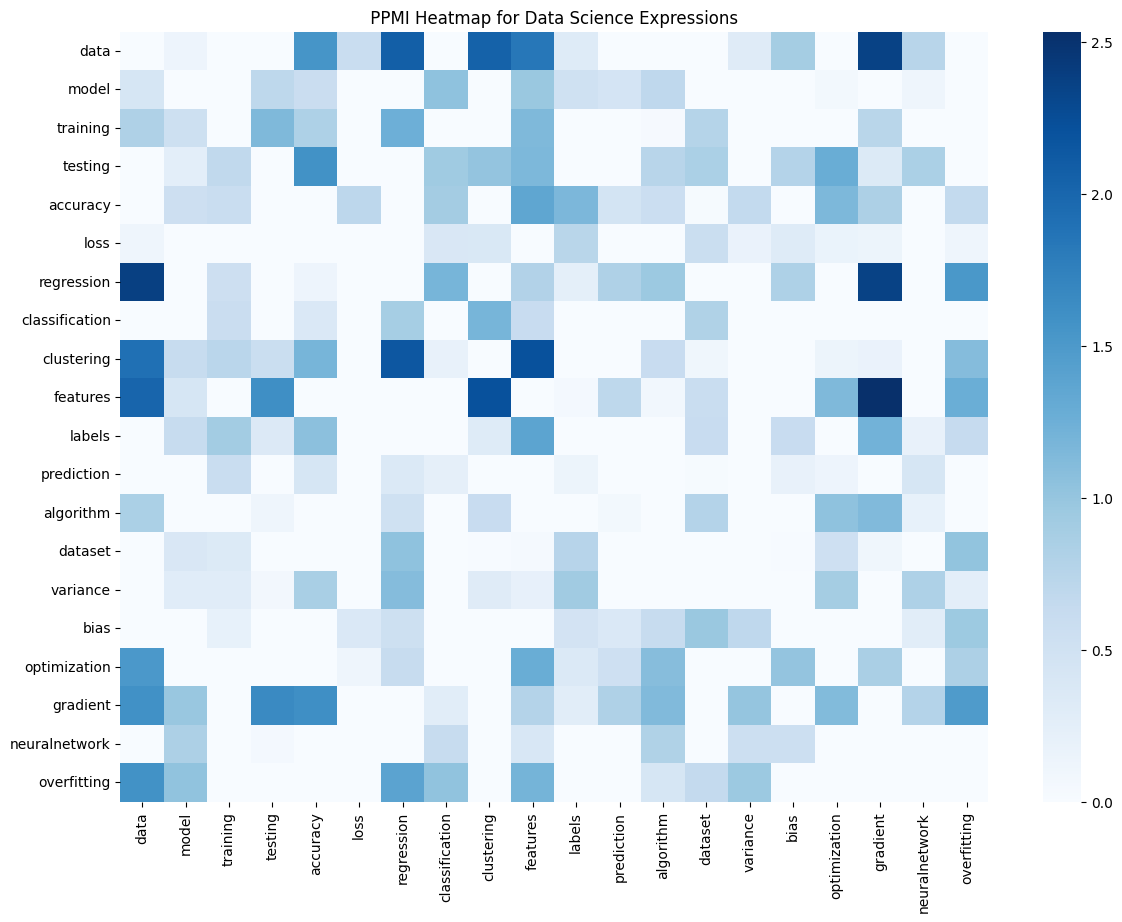

In [ ]:
###############################################################################################
#   Yousef Shihade
#   Task 4 - Option 3 "PPMI"
###############################################################################################


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

expressions = [
    "data", "model", "training", "testing", "accuracy",
    "loss", "regression", "classification", "clustering", "features",
    "labels", "prediction", "algorithm", "dataset", "variance",
    "bias", "optimization", "gradient", "neuralnetwork", "overfitting"
]

N = len(expressions)

#  Rndm frequency for each expression 20–100
rng = np.random.default_rng(42)
freq = rng.integers(20, 101, size=N)

#  Random co-occurrence counts for each pair
cooc = np.zeros((N, N), dtype=float)

for i in range(N):
    for j in range(N):
        if i == j:
            cooc[i, j] = 0
        else:
            max_c = min(freq[i], freq[j])
            cooc[i, j] = rng.integers(0, max_c + 1)

df_cooc = pd.DataFrame(cooc, index=expressions, columns=expressions)

print(" Co-occurrence mtrix ( first 5 rows ) : ")
display(df_cooc.head())


total = cooc.sum()
# Probs
P_wc = cooc / total
P_w = freq / freq.sum()
P_c = freq / freq.sum()

PPMI = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if P_wc[i, j] == 0:
            PPMI[i, j] = 0
        else:
            PMI = np.log2(P_wc[i, j] / (P_w[i] * P_c[j]))
            PPMI[i, j] = max(PMI, 0)

df_ppmi = pd.DataFrame(PPMI, index=expressions, columns=expressions)

print(" PPMI mtrix:")
display(df_ppmi)

plt.figure(figsize=(14, 10))
sns.heatmap(df_ppmi, cmap="Blues", annot=False)
plt.title(" PPMI Heatmap for Data Science Expressions ")
plt.show()